In [13]:
LINKEDIN_QUERY_PROMPT = """
You are a professional LinkedIn talent sourcing assistant.

Your primary responsibility is to generate precise LinkedIn Boolean search queries for hiring purposes.

User Input:
{user_input}

Instructions:

1. If the user input is related to hiring, recruitment, job roles, or candidate sourcing:
   - Extract role, skills, experience, and location (if available)
   - Generate a clean and concise LinkedIn Boolean search query
   - Output ONLY the search query (no explanation)

Examples:

Input: "Looking for Java developers with Spring Boot in Bangalore"
Output: ("Java Developer" OR "Java Engineer") AND ("Spring Boot") AND ("Bangalore")

Input: "Need frontend engineers skilled in React and TypeScript"
Output: ("Frontend Developer" OR "Frontend Engineer") AND ("React") AND ("TypeScript")

Input: "Hiring data scientists with Python, ML experience in India"
Output: ("Data Scientist") AND ("Python") AND ("Machine Learning" OR "ML") AND ("India")

Input: "Looking for blockchain developers with Solidity and Web3"
Output: ("Blockchain Developer") AND ("Solidity") AND ("Web3")

2. If the user input is a greeting or general conversation:
   - Respond politely and professionally
   - Example: "Hi, I am a LinkedIn sourcing assistant. How can I help you with hiring today?"

3. If the user input is unrelated to recruitment:
   - Respond professionally and restrict the scope
   - Example:
     "I am designed specifically to assist with recruitment and LinkedIn candidate sourcing. Please provide hiring-related requirements so I can help you better."

Important:
- Do NOT generate search queries for irrelevant inputs
- Keep responses professional and concise
- Prefer standard job title variations using OR
- Use AND between different categories (role, skills, location)
"""

In [ ]:
from __future__ import annotations
from dataclasses import dataclass
from typing import Any, Dict, List
import json
from langgraph.graph import StateGraph, START, END
from langgraph.runtime import Runtime
from typing_extensions import TypedDict

from IPython.display import Image,display

from dotenv import load_dotenv
import os

import requests

# import LINKEDIN_QUERY_PROMPT
# from prompt_templates.user_intent_prompt import INTENT_CLASSIFIER_PROMPT


In [15]:
class Context(TypedDict):
    """Context parameters for the agent.

    Set these when creating assistants OR when invoking the graph.
    See: https://langchain-ai.github.io/langgraph/cloud/how-tos/configuration_cloud/
    """

    my_configurable_param: str

class State(TypedDict):
    """Input state for the agent.

    Defines the initial structure of incoming data.
    See: https://langchain-ai.github.io/langgraph/concepts/low_level/#state
    """
    user_prompt: str
    linkedin_query: str
    linkedin_results: List[str]    
    # google_query: str
    # google_results: list



In [16]:
def build_search_query_linkedin(state: State, runtime: Runtime[Context]) -> Dict[str, Any]:
    """Process input and returns output.

    Can use runtime context to alter behavior.
    """    
    LLM_BASE_URL = os.getenv("LLM_BASE_URL")
    
    prompt = LINKEDIN_QUERY_PROMPT.format(
        user_input=state.get('user_prompt')
    )
    
    data = {
    "model": "qwen2.5",
    "prompt": prompt
    }
        
    response = requests.post(
        LLM_BASE_URL+"/api/generate", 
        json=data, 
        stream=True
    )
        
    full_response = ""
    
    for line in response.iter_lines():
        if line:
            chunk = json.loads(line)
            full_response += chunk.get("response", "")
            print("full_response INSIDE::::::::::::::::::::::;", full_response)
    
    print("FULL RESPONSE OUTSIDE LOOP IS is:::::::::::::::::::::::::", full_response)
    
    state['linkedin_query'] = full_response
    
    return state
        
    # return {
    #     "changeme": "output from call_model. "
    #     f"Configured with {(runtime.context or {}).get('my_configurable_param')}"
    # }


In [17]:
def classify_intent(state):
    user_input = state.get("user_prompt")
    # Call LLM or simple rules
    LLM_BASE_URL = os.getenv("LLM_BASE_URL")
    
    prompt = LINKEDIN_QUERY_PROMPT.format(
        user_input=user_input
    )
    
    data = {
    "model": "qwen2.5",
    "prompt": prompt
    }
    
    response = requests.post(
        LLM_BASE_URL+"/api/generate", 
        json=data, 
        stream=True
    )
        
    full_response = ""
    
    for line in response.iter_lines():
        if line:
            chunk = json.loads(line)
            full_response += chunk.get("response", "")
            print("full_response INSIDE::::::::::::::::::::::;", full_response)
    
    print("FULL RESPONSE OUTSIDE LOOP IS is:::::::::::::::::::::::::", full_response)
    
    state['linkedin_query'] = full_response
    
    # Output: "recruitment" | "greeting" | "irrelevant"

In [33]:
def search_linkedin_profiles(state: State, runtime: Runtime[Context]) -> Dict[str, Any]: 
    base_url =  os.getenv("SERPER_BASE_URL")
    
    endpoint = base_url+"/search"
    
    searchQuery = f'site:linkedin.com/in {state.get("linkedin_query")}'
    
    print("searchQuery::::::::::::", searchQuery)
    
    payload = {
        "q": searchQuery,
        "num": 10
    }

    headers = {
        "X-API-KEY": os.getenv("SERPER_API_KEY"),
        "Content-Type": "application/json"
    }

    response = requests.post(endpoint, json=payload, headers=headers)
    data = response.json()
    
    results = []

    for item in data.get("organic", []):
        link = item.get("link", "")
        
        if "linkedin.com/in" in link:
            results.append({
                "title": item.get("title"),
                "snippet": item.get("snippet"),
                "url": link
            })
    print("results:::::::::::::::::::::", results)
    if(len(results)):
        state['linkedin_results'] = results
        
    return state




In [34]:
graph = (
    StateGraph(State, context_schema=Context)
    # Nodes
    .add_node("build_search_query_linkedin", build_search_query_linkedin)
    .add_node("search_linkedin_profiles", search_linkedin_profiles)
    
    #Flow
    .add_edge(START, "build_search_query_linkedin")
    .add_edge("build_search_query_linkedin", "search_linkedin_profiles")
    .add_edge("search_linkedin_profiles", END)
    
    .compile(name="Talent Sourcing Graph")
)

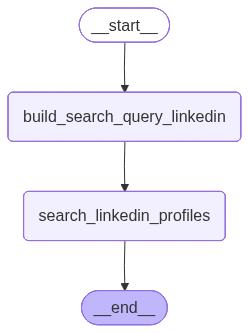

In [35]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [36]:
graph.invoke({"user_prompt": "I need java developers with 4+ years of experience location india"})

full_response INSIDE::::::::::::::::::::::; ("
full_response INSIDE::::::::::::::::::::::; ("Java
full_response INSIDE::::::::::::::::::::::; ("Java Developer
full_response INSIDE::::::::::::::::::::::; ("Java Developer"
full_response INSIDE::::::::::::::::::::::; ("Java Developer" OR
full_response INSIDE::::::::::::::::::::::; ("Java Developer" OR "
full_response INSIDE::::::::::::::::::::::; ("Java Developer" OR "Java
full_response INSIDE::::::::::::::::::::::; ("Java Developer" OR "Java Engineer
full_response INSIDE::::::::::::::::::::::; ("Java Developer" OR "Java Engineer")
full_response INSIDE::::::::::::::::::::::; ("Java Developer" OR "Java Engineer") AND
full_response INSIDE::::::::::::::::::::::; ("Java Developer" OR "Java Engineer") AND ("
full_response INSIDE::::::::::::::::::::::; ("Java Developer" OR "Java Engineer") AND ("4
full_response INSIDE::::::::::::::::::::::; ("Java Developer" OR "Java Engineer") AND ("4+
full_response INSIDE::::::::::::::::::::::; ("Java Develop

{'user_prompt': 'I need java developers with 4+ years of experience location india',
 'linkedin_query': '("Java Developer" OR "Java Engineer") AND ("4+ years of experience") AND ("India")',
 'linkedin_results': [{'title': 'Gaurav Jadhav | LinkedIn - LinkedIn',
   'snippet': 'Gaurav Jadhav. Java Developer with 4+ years of experience in Core Java, Spring Boot, Microservices, and RESTful APIs. Skilled in MongoDB, MySQL, Git, Maven, ...',
   'url': 'https://in.linkedin.com/in/gaurav-jadhav-2a4aa0200'},
  {'title': 'Mithun Hasure - Java Developer | 4 Years in JAVA8+ ... - LinkedIn',
   'snippet': 'Skilled Associate Software Engineer with 4 years of experience in designing and delivering scalable backend solutions for the Shipping, Transportation, ...',
   'url': 'https://in.linkedin.com/in/mithun-hasure'},
  {'title': 'Suryaprabha Ramakrishnan - Java Developer | 4+ Years Experience',
   'snippet': 'Suryaprabha Ramakrishnan. Java Developer | 4+ Years Experience | Spring Boot & Microservices 